In [1]:
import os
import cv2
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import skimage as ski
from PIL import Image
import matplotlib.pyplot as plt

## General parameters and helper functions

In [2]:
img_dir = os.path.join("iapr-26-uno-vision-challenge", "train_images")
annotations_file = os.path.join("iapr-26-uno-vision-challenge", "train") + '.csv'
annotations = pd.read_csv(annotations_file)

def get_random_imagepath(img_dir, annotations):
    image_id_list = list(annotations['image_id'])
    image_id = random.choice(image_id_list)
    return os.path.join(img_dir, image_id) + '.jpg'

def load_image(image_path, display=True):
    assert os.path.exists(image_path), "Image not found, please check directory structure"
    img = np.array(Image.open(image_path))
    if (display):
        print(image_path)
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    return img

## Separate the cases
There are two cases, one with a white background (black box indicator) and another with a colorful background (yellow box indicator).

In [3]:
def determine_case(img, thresh=200):
    return int(np.mean(img) < thresh)

In [4]:
player_name_order = ["p3", "p2", "p4", "p1"]

def rgb_threshold(img, r_thresh, g_thresh, b_thresh):
    img = img.copy()
    img_r = img[:,:,0]
    img_g = img[:,:,1]
    img_b = img[:,:,2]
    img_thresh_r = (img_r >= r_thresh[0]) & (img_r < r_thresh[1])
    img_thresh_g = (img_g >= g_thresh[0]) & (img_g < g_thresh[1])
    img_thresh_b = (img_b >= b_thresh[0]) & (img_b < b_thresh[1])
    img_thresh = (img_thresh_r & img_thresh_g) & img_thresh_b
    return img_thresh

def find_player(im_obj):
    M, N = np.shape(im_obj)
    mean = np.zeros(4)
    for i in range(2):
        for j in range(2):
            cropped_img = im_obj[i*M//2: M//2+i*M//2, j*N//2:N//2+j*N//2]
            #mean[0]=p3, mean[1]=p2, mean[2]= p4, mean[3]=p1
            mean[2*i + j] = np.mean(cropped_img, axis=(0,1))
    player_index = np.argmax(mean)
    player = player_name_order[player_index]
    return player

def detection_case_0(img, display=False):
    size_dilation = 5
    size_erosion = 50
    r_thresh = (40, 160)
    g_thresh = (40, 160)
    b_thresh = (40, 160)
    
    img_thresh = rgb_threshold(img.astype(np.int32), r_thresh, g_thresh, b_thresh)
    img_obj_dilation = ski.morphology.isotropic_dilation(img_thresh, size_dilation)
    img_obj = ski.morphology.isotropic_erosion(img_obj_dilation, size_erosion)
    player = find_player(img_obj)
    if (display):
        plt.imshow(img_thresh)
        plt.show()
        plt.imshow(img_obj_dilation)
        plt.show()
        plt.imshow(img_obj)
        plt.show()
    return player

def detection_case_1(img, display=False):
    size_dilation = 5
    size_erosion = 50
    r_thresh = (245, 256)
    g_thresh = (200, 230)
    b_thresh = (0, 100)
    
    img_thresh = rgb_threshold(img.astype(np.int32), r_thresh, g_thresh, b_thresh)
    img_obj_dilation = ski.morphology.isotropic_dilation(img_thresh, size_dilation)
    img_obj = ski.morphology.isotropic_erosion(img_obj_dilation, size_erosion)
    player = find_player(img_obj)
    if (display):
        plt.imshow(img_thresh)
        plt.show()
        plt.imshow(img_obj_dilation)
        plt.show()
        plt.imshow(img_obj)
        plt.show()
    return player

# Final detection

iapr-26-uno-vision-challenge\train_images\L1000967.jpg


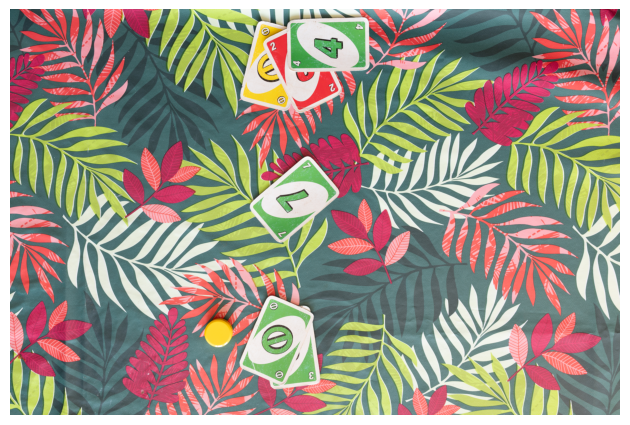

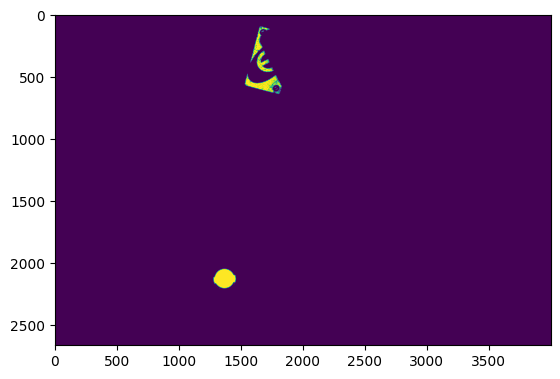

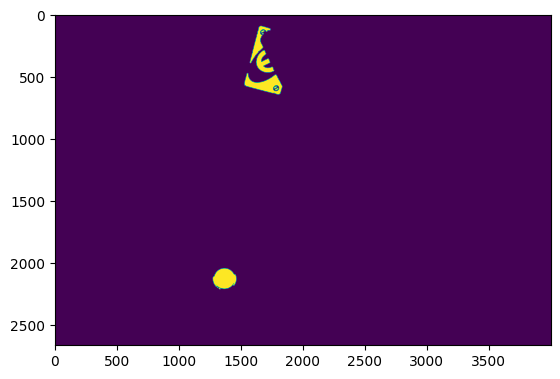

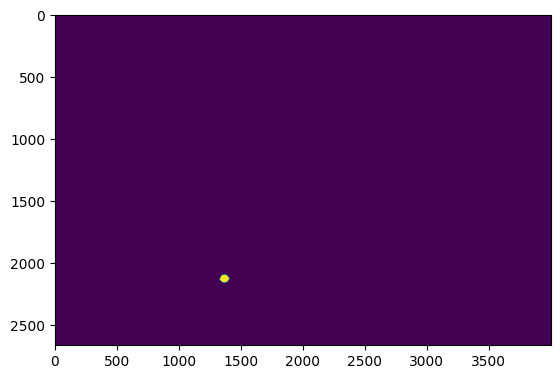

1
p4


In [5]:
def detection_player(img, display=False):
    case = determine_case(img)
    player = 'p1'
    if (case == 0):
        player = detection_case_0(img, display=display)
    else:
        player = detection_case_1(img, display=display)
    if (display):
        print(case)
        print(player)
    return player
        
#image_path = get_random_imagepath(img_dir, annotations)
# L1000967, L1000974
image_path = os.path.join(img_dir, "L1000967") + '.jpg'
img = load_image(image_path)
player = detection_player(img, display=True)

In [6]:
# Test for all train images

all_correct = True
image_id_list = list(annotations['image_id'])
active_player_list = list(annotations['active_player'])
for image_id, active_player in tqdm(zip(image_id_list, active_player_list), total=len(image_id_list)):
    image_path = os.path.join(img_dir, image_id) + '.jpg'
    img = load_image(image_path, display=False)
    player = detection_player(img, display=False)
    all_correct = all_correct and (player == active_player)
    if (player != active_player):
        print(image_id)
print(f"All detection correct = {all_correct}")

 80%|█████████████████████████████████████████████████████████████████▊                | 65/81 [04:46<01:07,  4.20s/it]

L1000967


 89%|████████████████████████████████████████████████████████████████████████▉         | 72/81 [05:18<00:39,  4.42s/it]

L1000974


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [05:57<00:00,  4.41s/it]

All detection correct = False


### Threshold test

iapr-26-uno-vision-challenge/train_images/L1000979.jpg


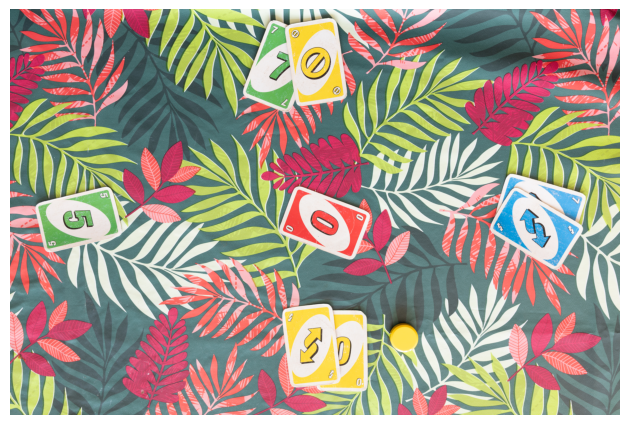

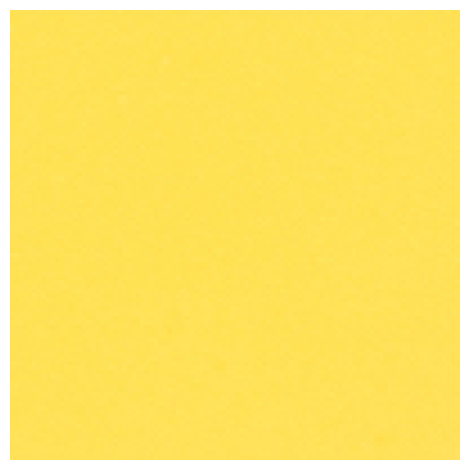

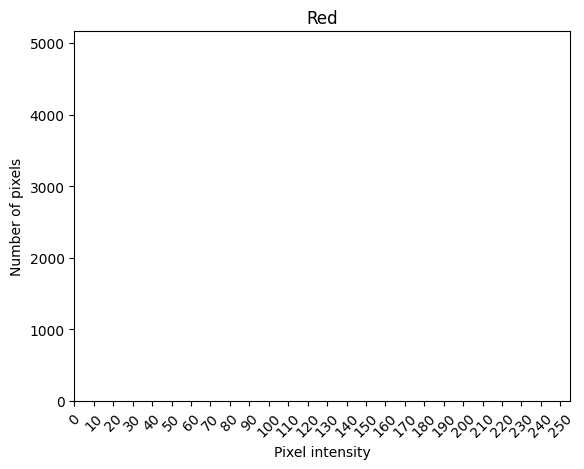

254.3544


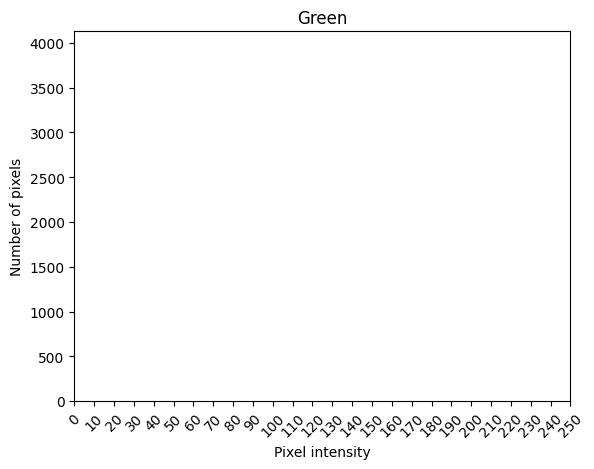

225.5376


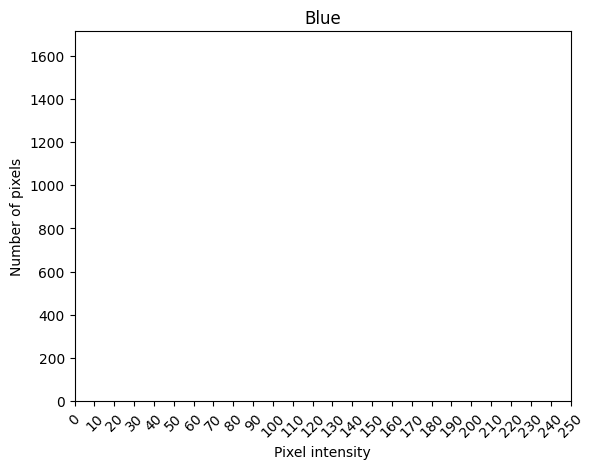

86.2226


In [7]:
#image_path = "iapr-26-uno-vision-challenge/train_images/L1000837.jpg"
#img = load_image(image_path)
#img = img[2400:2550, 2200:2300, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000775.jpg"
#img = load_image(image_path)
#img = img[2150:2280, 370:600, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000784.jpg"
#img = load_image(image_path)
#img = img[520:620, 3500:3600, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000977.jpg"
#img = load_image(image_path)
#img = img[2250:2300, 2250:2400, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000964.jpg"
#img = load_image(image_path)
#img = img[300:350, 1600:1650, :]

image_path = "iapr-26-uno-vision-challenge/train_images/L1000979.jpg"
img = load_image(image_path)
img = img[2110:2210, 2540:2640, :]


plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

img_red = img.copy()[:,:,0]
img_green = img.copy()[:,:,1]
img_blue = img.copy()[:,:,2]
# Display histograms
plt.hist(img_red.ravel(), bins=256)
plt.xlabel('Pixel intensity')
plt.ylabel('Number of pixels')
plt.title('Red')
plt.xticks(np.arange(0, 256, 10), rotation=45)
plt.show()
print(img_red.mean())

plt.hist(img_green.ravel(), bins=256)
plt.xlabel('Pixel intensity')
plt.ylabel('Number of pixels')
plt.title('Green')
plt.xticks(np.arange(0, 256, 10), rotation=45)
plt.show()
print(img_green.mean())

plt.hist(img_blue.ravel(), bins=256)
plt.xlabel('Pixel intensity')
plt.ylabel('Number of pixels')
plt.title('Blue')
plt.xticks(np.arange(0, 256, 10), rotation=45)
plt.show()
print(img_blue.mean())